In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits as afits
from scipy import integrate
import corner
from scipy.interpolate import RegularGridInterpolator
import h5py
from speclib import Spectrum
import speclib as sl
import astropy.units as u

In [2]:
## -- Visit 1 contrasts
# fleck
l1 = np.load('./data/contrasts/v1298tau_c_fleckcontrasts.npz')
waves1 = l1['waves']
wavehws1 = l1['wavehws']
cfleck1 = l1['C']
cerrfleck1 = l1['Cerr']

## -- Visit 2 contrasts
# fleck
waves2, wavehws2, cfleck2, cerrfleck2 = np.loadtxt('./data/contrasts/V1298Tau_contrasts_SOSSbd_fleck8_R100_v1.txt', skiprows=1, unpack=True)

# remove bin at 1.084 microns (helium absorption)
waves2 = np.delete(waves2, [20])
wavehws2 = np.delete(wavehws2, [20])
cfleck2 = np.delete(cfleck2, [20])
cerrfleck2 = np.delete(cerrfleck2, [20])

In [3]:
## -- load best-fit models and approx. model errors
l = np.load('./data/contrasts/bestfitmodels_all.npz')

bfmodel_v12c = l['bfmodel_v12c']
bfmodelerrs_v12c = l['bfmodelerrs_v12c']

bfmodel_v22c = l['bfmodel_v22c']
bfmodelerrs_v22c = l['bfmodelerrs_v22c']

bfmodel_v13c = l['bfmodel_v13c']
bfmodelerrs_v13c = l['bfmodelerrs_v13c']

bfmodel_v23c = l['bfmodel_v23c']
bfmodelerrs_v23c = l['bfmodelerrs_v23c']
del l

## -- load best-fit values
l = np.load('./data/contrasts/fits_all.npz')
fits_v12c, errs_v12c, uperrs_v12c, loerrs_v12c = l['fits_v12c'], l['errs_v12c'], l['uperrs_v12c'], l['loerrs_v12c']
fits_v13c, errs_v13c, uperrs_v13c, loerrs_v13c = l['fits_v13c'], l['errs_v13c'], l['uperrs_v13c'], l['loerrs_v13c']
fits_v22c, errs_v22c, uperrs_v22c, loerrs_v22c = l['fits_v22c'], l['errs_v22c'], l['uperrs_v22c'], l['loerrs_v22c']
fits_v23c, errs_v23c, uperrs_v23c, loerrs_v23c = l['fits_v23c'], l['errs_v23c'], l['uperrs_v23c'], l['loerrs_v23c']

In [4]:
## -- load forward model comparisons

l = np.load('./data/contrasts/forwardmodels_all.npz')
# 2-component, Tphot, Tspot = spectrum-derived values
fmodel1_v1 = l['fmodel_v1_TphotTcool']
fmodel1_v2 = l['fmodel_v2_TphotTcool']

thetafm1_v1 = np.array([4893.0, 3400.0])
thetafm1_v2 = np.array([4876.0, 3401.0])
# 2-component, Tphot=spectrum-derived values, Tspot=penumbra values
fmodel2_v1 = l['fmodel_v1_TphotTpen']
fmodel2_v2 = l['fmodel_v2_TphotTpen']
del l

thetafm2_v1 = np.array([4893.0, 4659])
thetafm2_v2 = np.array([4876.0, 4449])

# MURaM model fits, visit 1
mv1 = np.load('./data/contrasts/MURaM_models/bestfitmodels_visit1.npz')
mmodelK_v1 = mv1['bfmodelK'] # K0
bfAuApK_v1 = mv1['fitK']
mmodelG_v1 = mv1['bfmodelG'] # G2
bfAuApG_v1 = mv1['fitG']
del mv1

# MURaM model fits, visit 2
mv2 = np.load('./data/contrasts/MURaM_models/bestfitmodels_visit2.npz')
mmodelK_v2 = mv2['bfmodelK'] # K0
bfAuApK_v2 = mv2['fitK']
mmodelG_v2 = mv2['bfmodelG'] # G2
bfAuApG_v2 = mv2['fitG']
del mv2

In [5]:
## -- goodness of fits
def computeChi2(ydata, yerr, modely):
    chi_array = ((ydata - modely) ** 2. / yerr ** 2.)
    return np.sum(chi_array)

dof_2c = 104
dof_3c = 102

chi2_v12c = computeChi2(cfleck1, cerrfleck1, bfmodel_v12c) / dof_2c
chi2_v13c = computeChi2(cfleck1, cerrfleck1, bfmodel_v13c) / dof_3c

chi2_v22c = computeChi2(cfleck2, cerrfleck2, bfmodel_v22c) / dof_2c
chi2_v23c = computeChi2(cfleck2, cerrfleck2, bfmodel_v23c) / dof_3c

In [6]:
c2 = 'purple'
c3 = 'red'
c_fm1 = 'lightblue'
c_fm2 = 'lime'
c_mK = 'darkorange'
c_mG = 'gold'

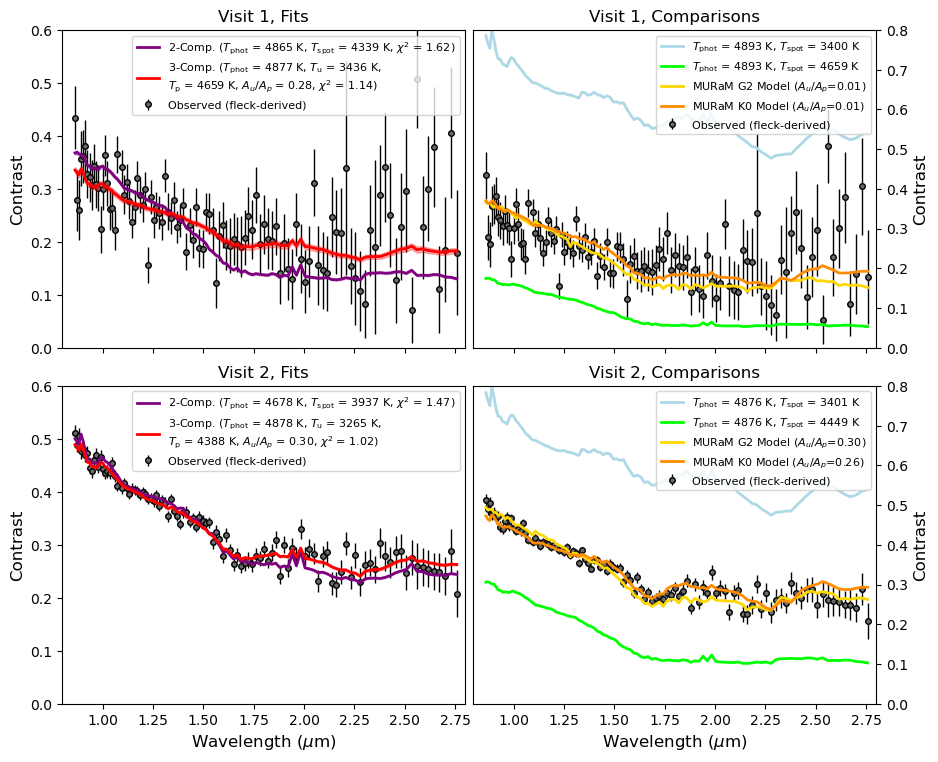

In [7]:
fig, ax = plt.subplots(figsize=(7*1.5,7*1.25), nrows=2, ncols=2, sharex=True)
plt.subplots_adjust(hspace=0.12, wspace=0.02)
## top left, visit 1 fits
ax[0,0].set_title('Visit 1, Fits', fontsize=12)
ax[0,0].errorbar(waves1, cfleck1, cerrfleck1, ls='None', marker='o', c='black', mfc='dimgray', lw=1, zorder=1, ms=4, label='Observed (fleck-derived)', rasterized=True)
ax[0,0].set_ylim(0,0.6)
ax[0,0].set_ylabel('Contrast', fontsize=12)
ax[0,0].set_xlim(0.8, 2.8)

ax[0,0].fill_between(waves1, (bfmodel_v12c-bfmodelerrs_v12c), (bfmodel_v12c+bfmodelerrs_v12c), ec=c2, fc=c2, zorder=2, alpha=0.3)
ax[0,0].plot(waves1, bfmodel_v12c, c=c2, lw=2, zorder=3, label=rf"2-Comp. ($T_\mathrm{{phot}}$ = {fits_v12c[0]:.0f} K, $T_\mathrm{{spot}}$ = {fits_v12c[1]:.0f} K, $\chi^2$ = {chi2_v12c:.2f})")

ax[0,0].fill_between(waves1, (bfmodel_v13c-bfmodelerrs_v13c), (bfmodel_v13c+bfmodelerrs_v13c), ec=c3, fc=c3, zorder=4, alpha=0.3)
ax[0,0].plot(waves1, bfmodel_v13c, c=c3, lw=2, zorder=5, label=rf"3-Comp. ($T_\mathrm{{phot}}$ = {fits_v13c[0]:.0f} K, $T_\mathrm{{u}}$ = {fits_v13c[1]:.0f} K,"+f"\n$T_\mathrm{{p}}$ = {fits_v13c[2]:.0f} K, $A_u/A_p$ = {fits_v13c[3]:.2f}, $\chi^2$ = {chi2_v13c:.2f})")
ax[0,0].legend(loc='upper right', fontsize=8)

## top right, visit 1 comparisons
ax[0,1].yaxis.set_label_position("right")
ax[0,1].yaxis.tick_right()
ax[0,1].set_title('Visit 1, Comparisons', fontsize=12)
ax[0,1].errorbar(waves1, cfleck1, cerrfleck1, ls='None', marker='o', c='black', mfc='dimgray', lw=1, zorder=1, ms=4, label='Observed (fleck-derived)', rasterized=True)
ax[0,1].set_ylim(0,0.8)
ax[0,1].set_ylabel('Contrast', fontsize=12)
ax[0,1].set_xlim(0.8, 2.8)

ax[0,1].plot(waves1, fmodel1_v1, lw=2, c=c_fm1, label=rf"$T_\mathrm{{phot}}$ = {thetafm1_v1[0]:.0f} K, $T_\mathrm{{spot}}$ = {thetafm1_v1[1]:.0f} K")
ax[0,1].plot(waves1, fmodel2_v1, lw=2, c=c_fm2, label=rf"$T_\mathrm{{phot}}$ = {thetafm2_v1[0]:.0f} K, $T_\mathrm{{spot}}$ = {thetafm2_v1[1]:.0f} K")
ax[0,1].plot(waves1, mmodelG_v1, lw=2, c=c_mG, label=r"MURaM G2 Model ($A_u/A_p$=%.2f)"%(bfAuApG_v1))
ax[0,1].plot(waves1, mmodelK_v1, lw=2, c=c_mK, label=r"MURaM K0 Model ($A_u/A_p$=%.2f)"%(bfAuApK_v1))
ax[0,1].legend(loc='upper right', fontsize=8)



## bottom left, visit 2 fits
ax[1,0].set_title('Visit 2, Fits', fontsize=12)
ax[1,0].errorbar(waves2, cfleck2, cerrfleck2, ls='None', marker='o', c='black', mfc='dimgray', lw=1, zorder=1, ms=4, label='Observed (fleck-derived)', rasterized=True)
ax[1,0].set_ylim(0,0.6)
ax[1,0].set_ylabel('Contrast', fontsize=12)
ax[1,0].set_xlim(0.8, 2.8)
ax[1,0].set_xlabel(r'Wavelength ($\mu$m)', fontsize=12)

ax[1,0].fill_between(waves2, (bfmodel_v22c-bfmodelerrs_v22c), (bfmodel_v22c+bfmodelerrs_v22c), ec=c2, fc=c2, zorder=2, alpha=0.3)
ax[1,0].plot(waves2, bfmodel_v22c, c=c2, lw=2, zorder=3, label=rf"2-Comp. ($T_\mathrm{{phot}}$ = {fits_v22c[0]:.0f} K, $T_\mathrm{{spot}}$ = {fits_v22c[1]:.0f} K, $\chi^2$ = {chi2_v22c:.2f})")

ax[1,0].fill_between(waves2, (bfmodel_v23c-bfmodelerrs_v23c), (bfmodel_v23c+bfmodelerrs_v23c), ec=c3, fc=c3, zorder=4, alpha=0.3)
ax[1,0].plot(waves2, bfmodel_v23c, c=c3, lw=2, zorder=5, label=rf"3-Comp. ($T_\mathrm{{phot}}$ = {fits_v23c[0]:.0f} K, $T_\mathrm{{u}}$ = {fits_v23c[1]:.0f} K,"+f"\n$T_\mathrm{{p}}$ = {fits_v23c[2]:.0f} K, $A_u/A_p$ = {fits_v23c[3]:.2f}, $\chi^2$ = {chi2_v23c:.2f})")
ax[1,0].legend(loc='upper right', fontsize=8)

## bottom right,
ax[1,1].set_title('Visit 2, Comparisons', fontsize=12)
ax[1,1].yaxis.set_label_position("right")
ax[1,1].yaxis.tick_right()
ax[1,1].errorbar(waves2, cfleck2, cerrfleck2, ls='None', marker='o', c='black', mfc='dimgray', lw=1, zorder=1, ms=4, label='Observed (fleck-derived)', rasterized=True)
ax[1,1].set_ylim(0,0.8)
ax[1,1].set_ylabel('Contrast', fontsize=12)
ax[1,1].set_xlim(0.8, 2.8)
ax[1,1].set_xlabel(r'Wavelength ($\mu$m)', fontsize=12)

ax[1,1].plot(waves2, fmodel1_v2, lw=2, c=c_fm1, label=rf"$T_\mathrm{{phot}}$ = {thetafm1_v2[0]:.0f} K, $T_\mathrm{{spot}}$ = {thetafm1_v2[1]:.0f} K")
ax[1,1].plot(waves2, fmodel2_v2, lw=2, c=c_fm2, label=rf"$T_\mathrm{{phot}}$ = {thetafm2_v2[0]:.0f} K, $T_\mathrm{{spot}}$ = {thetafm2_v2[1]:.0f} K")
ax[1,1].plot(waves2, mmodelG_v2, lw=2, c=c_mG, label=r"MURaM G2 Model ($A_u/A_p$=%.2f)"%(bfAuApG_v2))
ax[1,1].plot(waves2, mmodelK_v2, lw=2, c=c_mK, label=r"MURaM K0 Model ($A_u/A_p$=%.2f)"%(bfAuApK_v2))
ax[1,1].legend(loc='upper right', fontsize=8)

plt.savefig('./figures/Figure6_contrast_models.pdf', dpi=800, bbox_inches='tight')
plt.show()